# 01b — Récapitulatif des données générées

Ce notebook est à exécuter **après `01_generer_csv.ipynb`** et **avant `02_acp_analyse.ipynb`**.

Objectif : vérifier rapidement les données produites avant l’ACP, sans ajouter d’analyse complexe :

- nombre d’étudiants et nombre d’événements ;
- inventaire des CSV générés ;
- couverture des étudiants par métrique ;
- valeurs manquantes par variable et par étudiant ;
- distributions simples des métriques numériques.


## 1. Configuration

La détection automatique cherche le dossier `Chaine/`. Si besoin, vous pouvez fixer `PROJECT_DIR` manuellement dans la cellule suivante.


In [1]:
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

def detect_project_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "Chaine",
        Path.cwd() / "chaine_extracted" / "Chaine",
        Path.cwd().parent / "Chaine",
    ]
    for candidate in candidates:
        if (candidate / "csv").exists() and (
            (candidate / "data" / "MainTable.csv").exists() or (candidate / "scripts").exists()
        ):
            return candidate.resolve()
    raise FileNotFoundError(
        "Impossible de détecter automatiquement le dossier Chaine. "
        "Modifiez PROJECT_DIR manuellement dans cette cellule."
    )

# Décommentez et adaptez si la détection automatique ne fonctionne pas.
# PROJECT_DIR = Path(r"C:/Users/.../Chaine")
PROJECT_DIR = detect_project_dir()

DATA_DIR = PROJECT_DIR / "data"
CSV_DIR = PROJECT_DIR / "csv"
LOG_DIR = CSV_DIR / "logs"
MAIN_TABLE_PATH = DATA_DIR / "MainTable.csv"

# Fichiers CSV à ne pas traiter comme des métriques par étudiant.
EXCLUDED_CSV = {"run_report.csv", "stats.csv"}

# Nombre maximal de variables à afficher dans les graphiques de distribution.
MAX_DISTRIBUTIONS = 6

print("Projet :", PROJECT_DIR)
print("MainTable :", MAIN_TABLE_PATH)
print("Dossier CSV :", CSV_DIR)


Projet : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine
MainTable : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine\data\MainTable.csv
Dossier CSV : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine\csv


## 2. Vue d’ensemble

Cette section donne un récapitulatif global : taille de la table principale, nombre d’étudiants, période couverte et nombre de fichiers de métriques.


In [2]:
def safe_read_csv(path: Path):
    try:
        return pd.read_csv(path), None
    except Exception as exc:
        return None, f"{type(exc).__name__}: {exc}"

main_table = None
if MAIN_TABLE_PATH.exists():
    main_table, main_error = safe_read_csv(MAIN_TABLE_PATH)
    if main_error:
        print(f"Lecture impossible de MainTable.csv : {main_error}")
else:
    print("MainTable.csv introuvable : le récapitulatif se basera uniquement sur les CSV générés.")

csv_paths = sorted(CSV_DIR.glob("*.csv")) if CSV_DIR.exists() else []
metric_tables = {}
inventory_rows = []

for path in csv_paths:
    df, error = safe_read_csv(path)
    row = {
        "fichier": path.name,
        "statut": None,
        "raison": "",
        "lignes": None,
        "colonnes": None,
        "etudiants_uniques": None,
        "variables": None,
        "valeurs_manquantes_pct": None,
    }

    if error:
        row.update(statut="ignoré", raison=f"lecture impossible : {error}")
        inventory_rows.append(row)
        continue

    row.update(lignes=df.shape[0], colonnes=df.shape[1])

    if path.name in EXCLUDED_CSV:
        row.update(statut="ignoré", raison="fichier de rapport/statistiques")
        inventory_rows.append(row)
        continue

    if "SubjectID" not in df.columns:
        row.update(statut="ignoré", raison="pas de colonne SubjectID")
        inventory_rows.append(row)
        continue

    df = df.drop_duplicates(subset=["SubjectID"], keep="first")
    metric_tables[path.stem] = df

    value_cols = [c for c in df.columns if c != "SubjectID"]
    missing_pct = df[value_cols].isna().mean().mean() * 100 if value_cols else 0

    row.update(
        statut="chargé",
        lignes=df.shape[0],
        colonnes=df.shape[1],
        etudiants_uniques=df["SubjectID"].nunique(),
        variables=", ".join(value_cols),
        valeurs_manquantes_pct=missing_pct,
    )
    inventory_rows.append(row)

inventory_df = pd.DataFrame(inventory_rows)

main_students = None
main_events = None
period_text = "Non disponible"

if main_table is not None and "SubjectID" in main_table.columns:
    main_students = main_table["SubjectID"].nunique()
    main_events = len(main_table)

if main_table is not None and "ServerTimestamp" in main_table.columns:
    timestamps = pd.to_datetime(main_table["ServerTimestamp"], errors="coerce")
    if timestamps.notna().any():
        period_text = f"{timestamps.min()} → {timestamps.max()}"

all_metric_subjects = set()
common_metric_subjects = None

for df in metric_tables.values():
    subjects = set(df["SubjectID"].dropna().astype(str))
    all_metric_subjects |= subjects
    common_metric_subjects = subjects if common_metric_subjects is None else common_metric_subjects & subjects

summary_rows = [
    ("Lignes dans MainTable.csv", main_events),
    ("Étudiants uniques dans MainTable.csv", main_students),
    ("Période couverte", period_text),
    ("CSV de métriques exploitables", len(metric_tables)),
    ("Étudiants présents dans au moins un CSV de métrique", len(all_metric_subjects)),
    ("Étudiants présents dans tous les CSV de métriques", len(common_metric_subjects or [])),
]

summary_df = pd.DataFrame(summary_rows, columns=["indicateur", "valeur"])
display(summary_df)


,indicateur,valeur
0,Lignes dans MainTable.csv,5710
1,Étudiants uniques dans MainTable.csv,131
2,Période couverte,2019-09-30 13:00:54 → 2019-09-30 13:59:50
3,CSV de métriques exploitables,11
4,Étudiants présents dans au moins un CSV de métrique,131
5,Étudiants présents dans tous les CSV de métriques,110


## 3. Inventaire des CSV produits

Le tableau liste les fichiers générés et indique lesquels sont utilisables comme métriques par étudiant.


,fichier,statut,raison,lignes,colonnes,etudiants_uniques,variables,valeurs_manquantes_pct
0,CompileCount.csv,chargé,,131,2,131,CompileCount,0.0
1,CompileSpan.csv,chargé,,110,2,110,CompileSpanMinutes,0.0
2,CompileSuccessRate.csv,chargé,,131,2,131,CompileSuccessRate,0.0
3,ErrorQuotient.csv,chargé,,110,2,110,ErrorQuotient,0.0
4,FirstCompileVsGlobalFirst.csv,chargé,,110,2,110,MinutesFromGlobalFirstCompile,0.0
5,FracLong.csv,chargé,,121,2,121,FracLong,0.0
6,LastCompileVsGlobalLast.csv,chargé,,110,2,110,MinutesToGlobalLastCompile,0.0
7,MeanTestScore.csv,chargé,,131,2,131,MeanTestScore,0.0
8,RED.csv,chargé,,110,2,110,RED,0.0
9,SessionCount.csv,chargé,,131,2,131,SessionCount,0.0


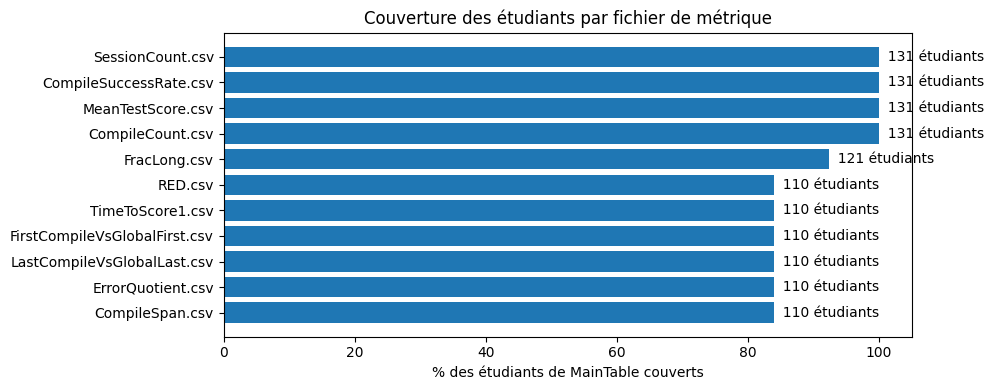

In [3]:
if inventory_df.empty:
    print("Aucun CSV trouvé dans le dossier csv/.")
else:
    display(inventory_df)

loaded_inventory = inventory_df[inventory_df["statut"] == "chargé"].copy()

if not loaded_inventory.empty:
    if main_students:
        loaded_inventory["couverture_etudiants_pct"] = (
            loaded_inventory["etudiants_uniques"] / main_students * 100
        )
        x_label = "% des étudiants de MainTable couverts"
        x_col = "couverture_etudiants_pct"
    else:
        loaded_inventory["couverture_etudiants_pct"] = loaded_inventory["etudiants_uniques"]
        x_label = "Nombre d'étudiants couverts"
        x_col = "couverture_etudiants_pct"

    coverage = loaded_inventory.sort_values(x_col, ascending=True)

    plt.figure(figsize=(10, max(4, 0.35 * len(coverage))))
    plt.barh(coverage["fichier"], coverage[x_col])
    plt.xlabel(x_label)
    plt.title("Couverture des étudiants par fichier de métrique")

    for y, (_, row) in enumerate(coverage.iterrows()):
        value = row[x_col]
        label = f"{int(row['etudiants_uniques'])} étudiants"
        plt.text(value, y, "  " + label, va="center")

    plt.tight_layout()
    plt.show()
else:
    print("Aucun CSV de métrique exploitable n'a été trouvé.")


## 4. Agrégation rapide des métriques

Cette agrégation reprend l’idée du notebook d’ACP, mais uniquement pour faire un contrôle qualité rapide : une ligne par étudiant, une colonne par métrique.


In [4]:
if not metric_tables:
    raise ValueError("Aucun CSV de métrique exploitable : exécutez d'abord 01_generer_csv.ipynb.")

tables = []
for name, df in metric_tables.items():
    df = df.copy()
    # Préfixe seulement en cas de collision de noms de colonnes rares.
    value_cols = [c for c in df.columns if c != "SubjectID"]
    renamed = {c: f"{name}_{c}" for c in value_cols if c in {"rows", "columns", "status"}}
    if renamed:
        df = df.rename(columns=renamed)
    tables.append(df)

features = reduce(lambda left, right: pd.merge(left, right, on="SubjectID", how="outer"), tables)

for col in features.columns:
    if col != "SubjectID":
        features[col] = pd.to_numeric(features[col], errors="coerce")

metric_cols = [c for c in features.columns if c != "SubjectID"]
features["nb_metriques_observees"] = features[metric_cols].notna().sum(axis=1)
features["pct_metriques_manquantes"] = features[metric_cols].isna().mean(axis=1) * 100

print(f"Table agrégée : {features.shape[0]:,} étudiants × {len(metric_cols):,} métriques")
print(f"Cellules de métriques manquantes : {features[metric_cols].isna().sum().sum():,} / {features[metric_cols].size:,}")

display(features.head())

missing_by_variable = (
    features[metric_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("pct_valeurs_manquantes")
    .reset_index()
    .rename(columns={"index": "variable"})
)

display(missing_by_variable)


Table agrégée : 131 étudiants × 11 métriques
Cellules de métriques manquantes : 136 / 1,441


,SubjectID,CompileCount,CompileSpanMinutes,CompileSuccessRate,ErrorQuotient,MinutesFromGlobalFirstCompile,FracLong,MinutesToGlobalLastCompile,MeanTestScore,RED,SessionCount,MinutesToScore1,nb_metriques_observees,pct_metriques_manquantes
0,0685c8001a43b03e0a155e1afa0c7bec2f4e82d24f7ce4843b25a441c45dd335,4,5.683333,1.000000,0.000000,12.366667,0.000000,40.516667,0.956522,0.000000,1,0.000000,11,0.000000
1,07445b2803cfbba249af9f27deaabc1c2aa5fd49745cd11637d45d1e8f939c2b,1,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,1,NaN,4,63.636364
2,080e819b7f2ec7fdf5df10abc0092a6ae39db49584244ea555a9ce18c8d57c53,5,4.566667,0.200000,0.750000,10.216667,0.000000,43.783333,0.200000,0.562500,1,4.566667,11,0.000000
3,091dc109aa58c7a670f4b61bc23df548fec73c05c7582dfb7c51f3a925d3618f,29,45.600000,0.896552,0.045455,5.916667,0.107143,7.050000,0.873358,0.022727,4,1.150000,11,0.000000
4,0973288c77f97c9245c444f90526bc6137bc40b48200197fd5bb6134f618f165,16,27.183333,0.812500,0.125000,11.300000,0.000000,20.083333,0.745722,0.062500,1,3.133333,11,0.000000


,variable,pct_valeurs_manquantes
0,CompileSpanMinutes,16.030534
1,MinutesFromGlobalFirstCompile,16.030534
2,ErrorQuotient,16.030534
3,MinutesToScore1,16.030534
4,RED,16.030534
5,MinutesToGlobalLastCompile,16.030534
6,FracLong,7.633588
7,CompileSuccessRate,0.000000
8,CompileCount,0.000000
9,MeanTestScore,0.000000


## 5. Valeurs manquantes

Deux vues simples :

1. quelles variables ont le plus de valeurs manquantes ;
2. combien de métriques sont observées par étudiant.


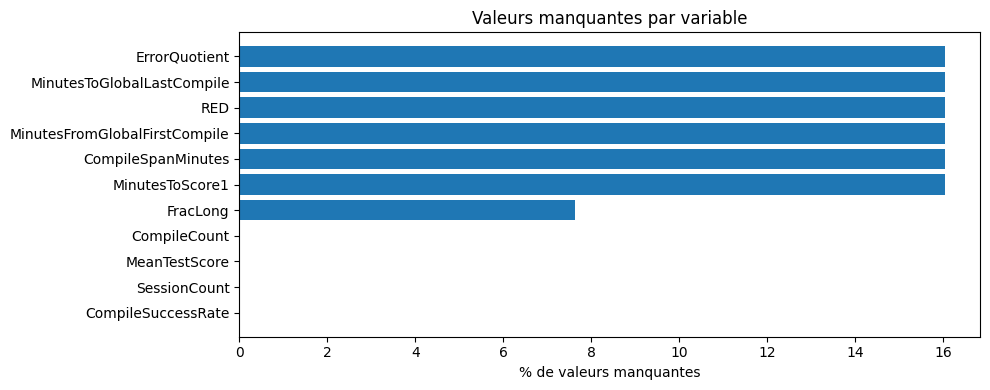

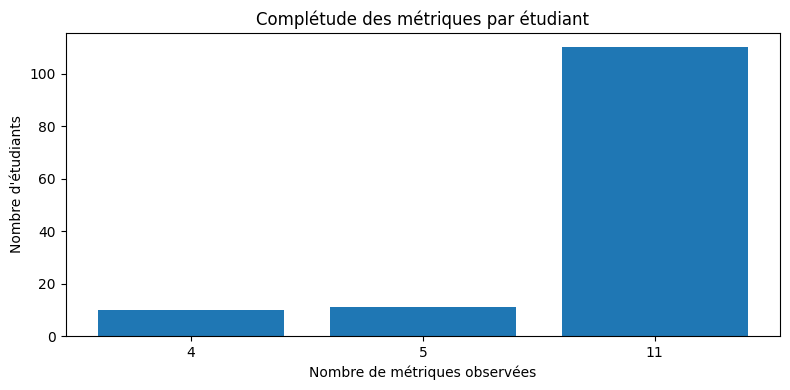

**Étudiants les moins complets, à vérifier si nécessaire :**

,SubjectID,nb_metriques_observees,pct_metriques_manquantes
1,07445b2803cfbba249af9f27deaabc1c2aa5fd49745cd11637d45d1e8f939c2b,4,63.636364
11,1e07cd29e230f3661645dcb909fda7759b80e0adf98716a5b82e22aa93a8223c,4,63.636364
18,2b2ac07813fde25641019289246d80a85054b31d93cd9dd4d8f4a3e717a017e1,4,63.636364
25,3c6c8b8647f1b51ec51557e9916c655923e73b1b0b8de099f40db81460e78611,4,63.636364
37,4ed6af94d2babfb73aae073691a59e8e6a1beb6bfaf77b75dac470cfc3b33199,4,63.636364
38,4f803c4f3466d829bc74ad7bf98f1767adad548d1c0d9e25b45b5b84b3220471,4,63.636364
40,53a6166821a8283bfffd1ba2d422ad4d81a71118145da6cba3f6134219ceaeb4,4,63.636364
55,6f8b95ec81c4c65578c705246889ade2223999b1383dbb36d4aae1502b94f22f,4,63.636364
64,8072f6579de3261211c2d30eb23619d2299179bf8835aed226d36f99aa88249d,4,63.636364
122,f3f68937b7087b8fa82118be631d144b10b8c5391b8a16f2affa093c1957edb1,4,63.636364


In [5]:
if not missing_by_variable.empty:
    plot_missing = missing_by_variable.sort_values("pct_valeurs_manquantes", ascending=True)

    plt.figure(figsize=(10, max(4, 0.35 * len(plot_missing))))
    plt.barh(plot_missing["variable"], plot_missing["pct_valeurs_manquantes"])
    plt.xlabel("% de valeurs manquantes")
    plt.title("Valeurs manquantes par variable")
    plt.tight_layout()
    plt.show()

observed_counts = features["nb_metriques_observees"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(observed_counts.index.astype(str), observed_counts.values)
plt.xlabel("Nombre de métriques observées")
plt.ylabel("Nombre d'étudiants")
plt.title("Complétude des métriques par étudiant")
plt.tight_layout()
plt.show()

least_complete = (
    features[["SubjectID", "nb_metriques_observees", "pct_metriques_manquantes"]]
    .sort_values(["nb_metriques_observees", "SubjectID"])
    .head(10)
)

display(Markdown("**Étudiants les moins complets, à vérifier si nécessaire :**"))
display(least_complete)
